<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1 — Persiapan

In [1]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Fase 2 — Pembersihan Data (Data Cleaning)

##  Cek Data yang Kosong

In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Hapus Kolom yang Tidak Berguna

In [5]:
df = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Mengisi Data Kosong pada Kolom Age

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].isnull().sum()

np.int64(0)

## Mengisi Data Kosong pada Kolom Embarked

In [7]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'].isnull().sum()

np.int64(0)

## Verifikasi Tidak Ada Lagi Data Kosong

In [8]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


## Mengubah Kolom Sex Menjadi Angka

In [9]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


## Mengubah Kolom Embarked Menjadi Angka

In [10]:
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


## Cek Hasil Akhir Pembersihan

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


# Fase 3 — Eksplorasi Data (EDA)

## Import Matplotlib

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

## Menghitung Berapa Persen Penumpang yang Selamat

In [13]:
df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


## Visualisasi Jumlah yang Selamat vs Tidak

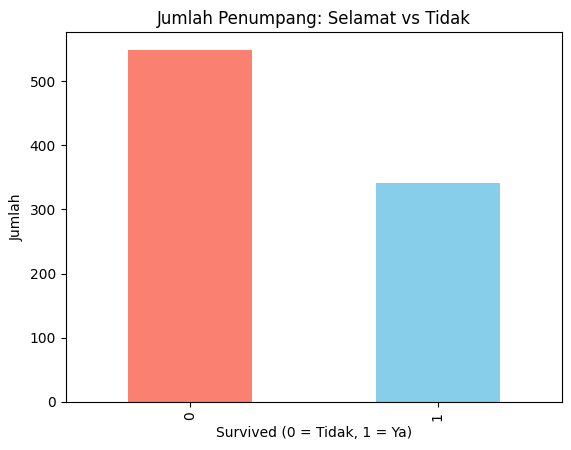

In [14]:
df['Survived'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title("Jumlah Penumpang: Selamat vs Tidak")
plt.xlabel('Survived (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.show()

## Menghitung Apakah Perempuan Lebih Banyak Selamat

In [15]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
0,0.188908
1,0.742038


## Visualisasi Survival Rate Berdasarkan Jenis Kelamin

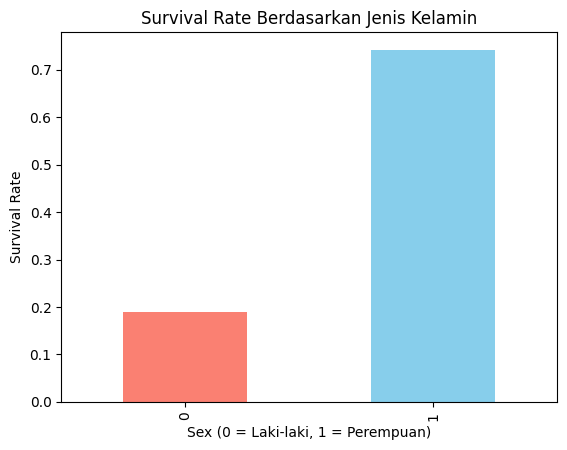

In [16]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Survival Rate Berdasarkan Jenis Kelamin')
plt.xlabel('Sex (0 = Laki-laki, 1 = Perempuan)')
plt.ylabel('Survival Rate')
plt.show()

## Analisis Apakah Kelas Tiket Memengaruhi Peluang Hidup

In [17]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


## Visualisasi Survival Rate Berdasarkan Kelas Tiket

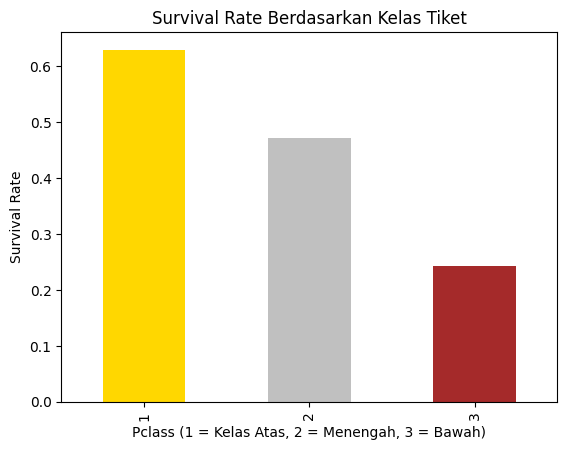

In [18]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Survival Rate Berdasarkan Kelas Tiket')
plt.xlabel('Pclass (1 = Kelas Atas, 2 = Menengah, 3 = Bawah)')
plt.ylabel('Survival Rate')
plt.show()

## Distribusi Umur Penumpang

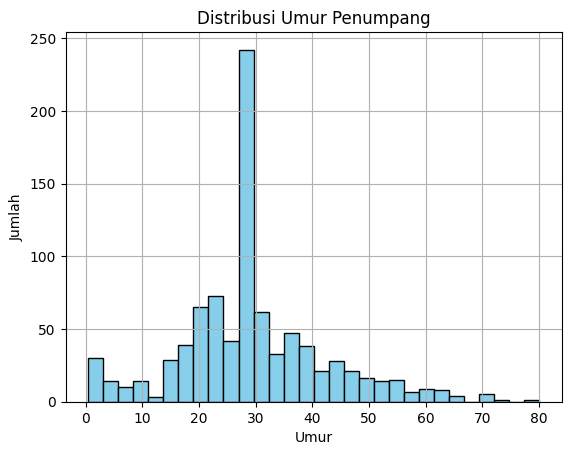

In [19]:
df['Age'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Distribusi Umur Penumpang')
plt.xlabel('Umur')
plt.ylabel('Jumlah')
plt.show()

## Ringkasan Statistik Keseluruhan

In [20]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208,0.361392
std,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.635673
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000


# Fase 4 — Modeling

## Menentukan Fitur (X) dan Target (y)

In [21]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print('Bentuk X:', X.shape)
print('Bentuk y:', y.shape)

Bentuk X: (891, 7)
Bentuk y: (891,)


## Membagi Data Menjadi Train dan Test

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Jumlah data latih:', X_train.shape[0])
print('Jumlah data uji:', X_test.shape[0])

Jumlah data latih: 712
Jumlah data uji: 179


## Membuat Model Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=200)

## Prediksi Menggunakan Logistic Regression

In [24]:
y_pred_lr = model_lr.predict(X_test)
y_pred_lr[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

## Membuat Model Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Prediksi Menggunakan Random Forest

In [26]:
y_pred_rf = model_rf.predict(X_test)
y_pred_rf[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1])

# Fase 5 — Evaluasi

## Import Metrik Evaluasi

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Accuracy Logistic Regression

In [28]:
acc_lr = accuracy_score(y_test, y_pred_lr)
print('Accuracy Logistic Regression:', round(acc_lr * 100, 2), '%')

Accuracy Logistic Regression: 79.89 %


## Accuracy Random Forest

In [29]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print('Accuracy Random Forest:', round(acc_rf * 100, 2), '%')

Accuracy Random Forest: 82.68 %


## Confusion Matrix Logistic Regression

In [30]:
print('Confusion Matrix - Logistic Regression:')
print(confusion_matrix(y_test, y_pred_lr))

Confusion Matrix - Logistic Regression:
[[89 16]
 [20 54]]


## Confusion Matrix Random Forest

In [31]:
print('Confusion Matrix - Random Forest:')
print(confusion_matrix(y_test, y_pred_rf))

Confusion Matrix - Random Forest:
[[92 13]
 [18 56]]


## Classification Report Logistic Regression

In [32]:
print('Classification Report - Logistic Regression:')
print(classification_report(y_test, y_pred_lr, target_names=['Tidak Selamat', 'Selamat']))

Classification Report - Logistic Regression:
               precision    recall  f1-score   support

Tidak Selamat       0.82      0.85      0.83       105
      Selamat       0.77      0.73      0.75        74

     accuracy                           0.80       179
    macro avg       0.79      0.79      0.79       179
 weighted avg       0.80      0.80      0.80       179



## Classification Report Random Forest

In [33]:
print('Classification Report - Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names=['Tidak Selamat', 'Selamat']))

Classification Report - Random Forest:
               precision    recall  f1-score   support

Tidak Selamat       0.84      0.88      0.86       105
      Selamat       0.81      0.76      0.78        74

     accuracy                           0.83       179
    macro avg       0.82      0.82      0.82       179
 weighted avg       0.83      0.83      0.83       179



## Perbandingan Kedua Model

In [34]:
print('=== Perbandingan Accuracy ===')
print('Logistic Regression :', round(acc_lr * 100, 2), '%')
print('Random Forest       :', round(acc_rf * 100, 2), '%')

if acc_rf > acc_lr:
  print('\nRandom Forest lebih unggul di dataset ini.')
elif acc_lr > acc_rf:
  print('\nLogistic Regression lebih unggul di dataset ini.')
else:
  print('\nKedua model punya performa yang sama.')

=== Perbandingan Accuracy ===
Logistic Regression : 79.89 %
Random Forest       : 82.68 %

Random Forest lebih unggul di dataset ini.


## Visualisasi Perbandingan Accuracy

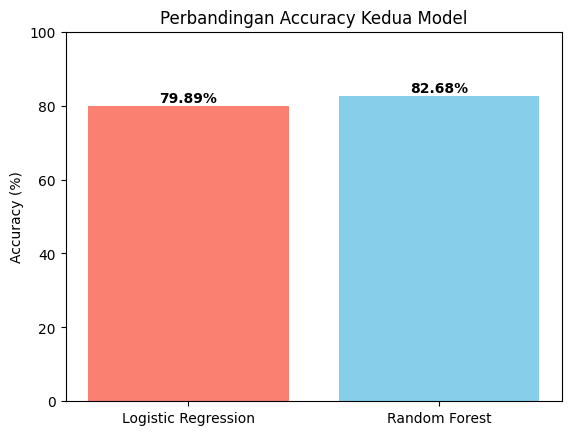

In [35]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [acc_lr * 100, acc_rf * 100]

plt.bar(models, accuracies, color=['salmon', 'skyblue'])
plt.title('Perbandingan Accuracy Kedua Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, acc in enumerate(accuracies):
  plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', fontweight='bold')

plt.show()